In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [7]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):

    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

In [8]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 1A


In [9]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [10]:
x_train_A = x_train
x_val_A = x_val
x_test_A = x_test

x_train_B = x_train / 255.0
x_val_B = x_val / 255.0
x_test_B = x_test / 255.0


mean = np.mean(x_train, axis=(0,1,2))
std = np.std(x_train, axis=(0,1,2))

x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

In [11]:
model_A = build_baseline_cnn()
history_A, acc_A, loss_A, time_A = train_and_evaluate(
    model_A, x_train_A, y_train, x_val_A, y_val, x_test_A, y_test
)

Test Acc: 0.5866 | Test Loss: 2.9144 | Time: 47.0s


In [12]:
model_B = build_baseline_cnn()
history_B, acc_B, loss_B, time_B = train_and_evaluate(
    model_B, x_train_B, y_train, x_val_B, y_val, x_test_B, y_test
)

Test Acc: 0.6567 | Test Loss: 1.4560 | Time: 44.6s


In [13]:
model_C = build_baseline_cnn()
history_C, acc_C, loss_C, time_C = train_and_evaluate(
    model_C, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test
)

Test Acc: 0.6571 | Test Loss: 2.2431 | Time: 45.9s


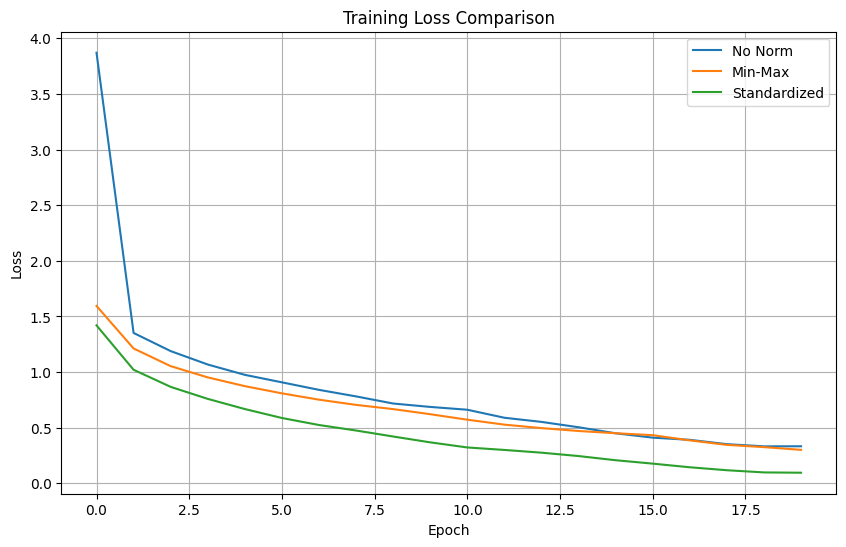

In [ ]:
plot_curves(
    [history_A, history_B, history_C],
    ['No Norm', 'Min-Max', 'Standardized'],
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)

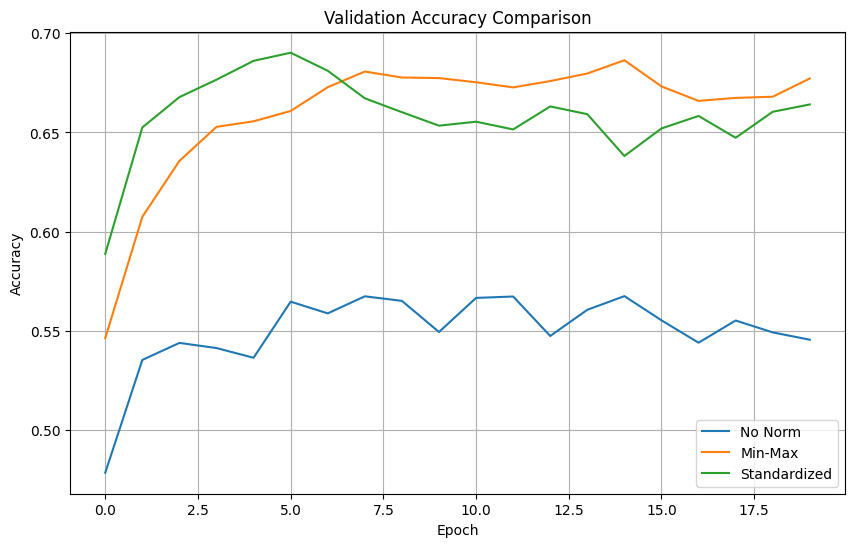

In [ ]:
plot_curves(
    [history_A, history_B, history_C],
    ['No Norm', 'Min-Max', 'Standardized'],
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

In [ ]:
train_acc_A = history_A.history['accuracy'][-1]
val_acc_A = history_A.history['val_accuracy'][-1]
test_acc_A = acc_A

train_acc_B = history_B.history['accuracy'][-1]
val_acc_B = history_B.history['val_accuracy'][-1]
test_acc_B = acc_B

train_acc_C = history_C.history['accuracy'][-1]
val_acc_C = history_C.history['val_accuracy'][-1]
test_acc_C = acc_C

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Preprocessing": ["None", "Min-Max", "Standardized"],
    "Train Acc": [train_acc_A, train_acc_B, train_acc_C],
    "Val Acc": [val_acc_A, val_acc_B, val_acc_C],
    "Test Acc": [test_acc_A, test_acc_B, test_acc_C],
})

print(results)

  Preprocessing  Train Acc  Val Acc  Test Acc
0          None   0.886275   0.5454    0.5493
1       Min-Max   0.897075   0.6772    0.6718
2  Standardized   0.968275   0.6641    0.6617


# **1B**

In [11]:
model_no_aug = build_baseline_cnn()

history_no_aug, acc_no_aug, loss_no_aug, time_no_aug = train_and_evaluate(
    model_no_aug,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test,
    epochs=40,
    batch_size=128
)

Test Acc: 0.6708 | Test Loss: 3.4744 | Time: 89.6s


In [2]:
import tensorflow as tf

In [12]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_C)

In [ ]:
model_aug = build_baseline_cnn()

start = time.time()

history_aug = model_aug.fit(
    datagen.flow(x_train_C, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_C, to_categorical(y_val, 10)),
    epochs=40,
    verbose=0
)

elapsed_aug = time.time() - start

test_loss_aug, test_acc_aug = model_aug.evaluate(
    x_test_C, to_categorical(y_test, 10), verbose=0
)

print(f"Test Acc: {test_acc_aug:.4f} | Time: {elapsed_aug:.1f}s")

Test Acc: 0.7788 | Time: 884.4s


In [13]:
model_aug = build_baseline_cnn()

start = time.time()

history_aug = model_aug.fit(
    datagen.flow(x_train_C, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_C, to_categorical(y_val, 10)),
    epochs=40,
    verbose=0
)

elapsed_aug = time.time() - start

test_loss_aug, test_acc_aug = model_aug.evaluate(
    x_test_C, to_categorical(y_test, 10), verbose=0
)

print(f"Test Acc: {test_acc_aug:.4f} | Time: {elapsed_aug:.1f}s")

Test Acc: 0.7770 | Time: 968.3s


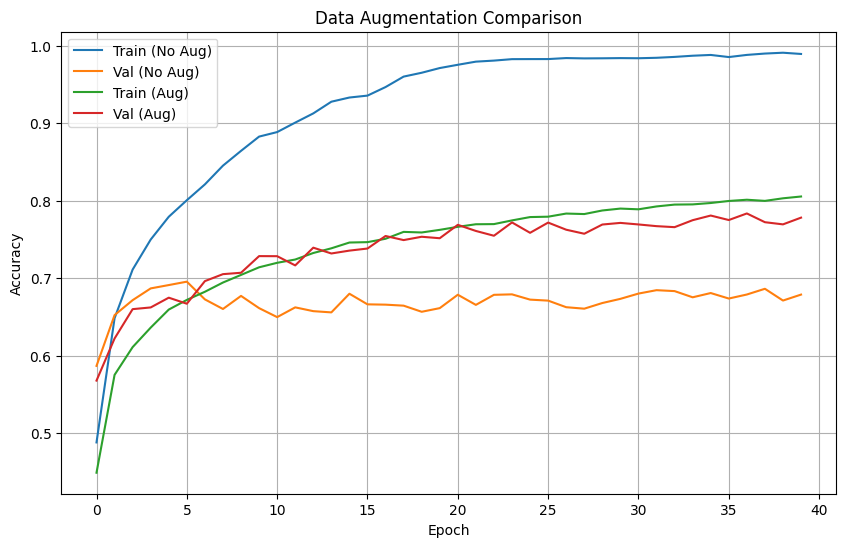

In [14]:
plt.figure(figsize=(10,6))

# no augmentation
plt.plot(history_no_aug.history['accuracy'], label='Train (No Aug)')
plt.plot(history_no_aug.history['val_accuracy'], label='Val (No Aug)')

# with augmentation
plt.plot(history_aug.history['accuracy'], label='Train (Aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val (Aug)')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Data Augmentation Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [16]:

gap_no_aug = (
    history_no_aug.history['accuracy'][-1]
    - history_no_aug.history['val_accuracy'][-1]
)


gap_aug = (
    history_aug.history['accuracy'][-1]
    - history_aug.history['val_accuracy'][-1]
)

print("Gap No Aug:", gap_no_aug)
print("Gap Aug:", gap_aug)

Gap No Aug: 0.310824990272522
Gap Aug: 0.027300000190734863


Augmentation overfits less

## 2A

In [5]:
# standardize data
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_std = (x_train - mean) / std
x_val_std = (x_val - mean) / std
x_test_std = (x_test - mean) / std


print(np.mean(x_train_std))
print(np.std(x_train_std))

4.0611885e-06
1.0000004


In [14]:
def build_cnn_model(f1,f2,f3,f4):

    model = models.Sequential([
        # layer 1
        layers.Conv2D(f1, (3,3), activation='relu',padding='same', input_shape=(32, 32, 3)),

        # layer 2
        layers.Conv2D(f2,(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D((2, 2)),

        # layer 3
        layers.Conv2D(f3,(3,3), activation='relu', padding='same'),

        # layer 4
        layers.Conv2D(f4,(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')

    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']

    )
    return model



models_config = {
    "Small": (8, 8, 16, 16),
    "Medium": (32, 32, 64, 64),
    "Large": (64, 64, 128, 128)
}

histories = []
labels = []
results = []

for name, (f1, f2, f3, f4) in models_config.items():

    print(f"\nTraining {name} model...")

    model = build_cnn_model(f1, f2, f3, f4)

    model.summary()

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )

    histories.append(history)
    labels.append(name)

    results.append({
        "Model": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })



Training Small model...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,786 (534.32 KB)

 Trainable params: 136,786 (534.32 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310,154 (5.00 MB)

 Trainable params: 1,310,154 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7377 | Test Loss: 1.9077 | Time: 142.3s


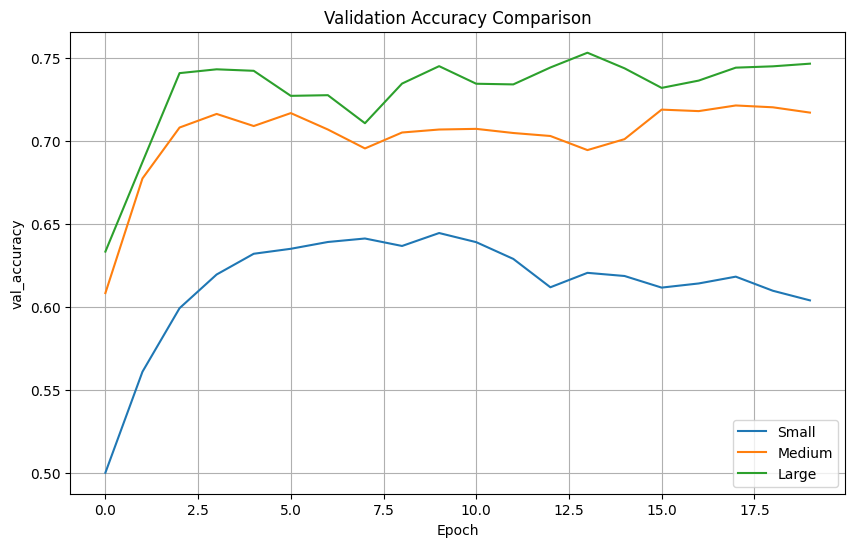

In [ ]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy Comparison'
)

**3A**

In [1]:
def build_cnn_dropout(drop_rate=0.0):

    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(drop_rate),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(drop_rate),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),

        layers.Dropout(drop_rate),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [15]:
model_D0 = build_cnn_dropout(0.0)
history_D0, acc_D0, loss_D0, t_D0 = train_and_evaluate(
    model_D0, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test,
    epochs=30
)

Test Acc: 0.7114 | Test Loss: 2.6139 | Time: 114.8s


In [16]:
model_D1 = build_cnn_dropout(0.25)
history_D1, acc_D1, loss_D1, t_D1 = train_and_evaluate(
    model_D1, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test,
    epochs=30
)

Test Acc: 0.7719 | Test Loss: 0.8938 | Time: 134.5s


In [17]:
model_D2 = build_cnn_dropout(0.5)
history_D2, acc_D2, loss_D2, t_D2 = train_and_evaluate(
    model_D2, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test,
    epochs=30
)

Test Acc: 0.7828 | Test Loss: 0.6362 | Time: 120.3s


In [18]:
gap_D0 = history_D0.history['accuracy'][-1] - history_D0.history['val_accuracy'][-1]
gap_D1 = history_D1.history['accuracy'][-1] - history_D1.history['val_accuracy'][-1]
gap_D2 = history_D2.history['accuracy'][-1] - history_D2.history['val_accuracy'][-1]

In [19]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["D0", "D1", "D2"],
    "Train Acc": [
        history_D0.history['accuracy'][-1],
        history_D1.history['accuracy'][-1],
        history_D2.history['accuracy'][-1]
    ],
    "Val Acc": [
        history_D0.history['val_accuracy'][-1],
        history_D1.history['val_accuracy'][-1],
        history_D2.history['val_accuracy'][-1]
    ],
    "Test Acc": [acc_D0, acc_D1, acc_D2],
    "Overfit Gap": [gap_D0, gap_D1, gap_D2]
})

print(results)

  Model  Train Acc  Val Acc  Test Acc  Overfit Gap
0    D0   0.988400   0.7125    0.7114     0.275900
1    D1   0.932025   0.7812    0.7719     0.150825
2    D2   0.798450   0.7876    0.7828     0.010850


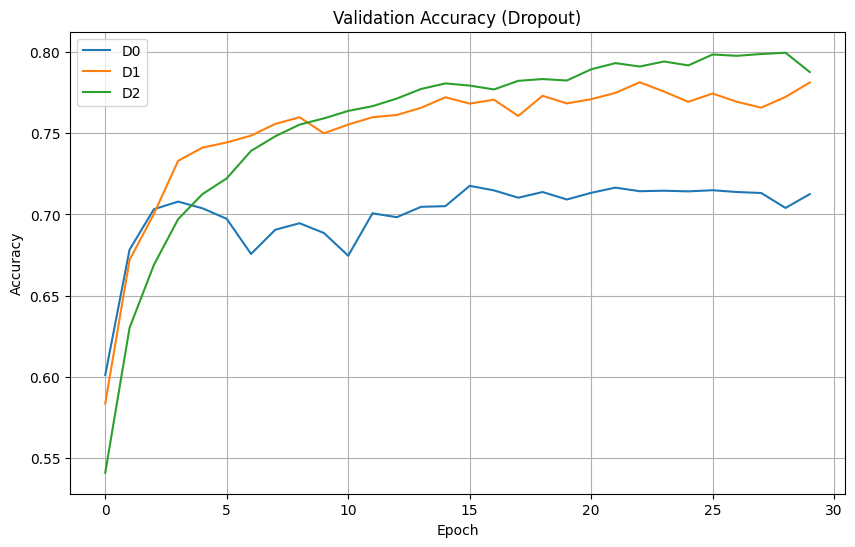

In [20]:
plot_curves(
    [history_D0, history_D1, history_D2],
    ['D0', 'D1', 'D2'],
    metric='val_accuracy',
    title='Validation Accuracy (Dropout)',
    ylabel='Accuracy'
)

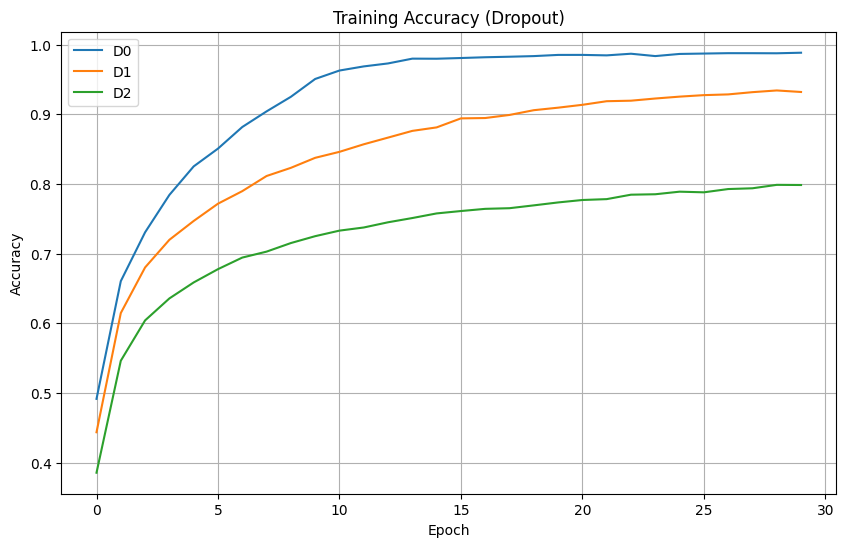

In [21]:
plot_curves(
    [history_D0, history_D1, history_D2],
    ['D0', 'D1', 'D2'],
    metric='accuracy',
    title='Training Accuracy (Dropout)',
    ylabel='Accuracy'
)

# **3B**

In [22]:
model = build_cnn_dropout(0.0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model_ES0 = build_cnn_dropout(0.0)

history_ES0, acc_ES0, loss_ES0, time_ES0 = train_and_evaluate(
    model_ES0,
    x_train_std, y_train,
    x_val_std, y_val,
    x_test_std, y_test,
    epochs=50
)

Test Acc: 0.7074 | Test Loss: 3.1159 | Time: 193.1s


In [24]:
es2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [25]:
model_ES2 = build_cnn_dropout(0.0)

history_ES2, acc_ES2, loss_ES2, time_ES2 = train_and_evaluate(
    model_ES2,
    x_train_std, y_train,
    x_val_std, y_val,
    x_test_std, y_test,
    epochs=50,
    extra_callbacks=[es2]
)

Test Acc: 0.7155 | Test Loss: 0.8578 | Time: 39.6s


In [26]:
es3 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)



model_ES3 = build_cnn_dropout(0.0)

history_ES3, acc_ES3, loss_ES3, time_ES3 = train_and_evaluate(
    model_ES3,
    x_train_std, y_train,
    x_val_std, y_val,
    x_test_std, y_test,
    epochs=50,
    extra_callbacks=[es3]
)

Test Acc: 0.6939 | Test Loss: 0.9025 | Time: 53.5s


In [27]:
stopped_ES2 = len(history_ES2.history['loss'])
stopped_ES3 = len(history_ES3.history['loss'])


best_val_loss_ES0 = min(history_ES0.history['val_loss'])
best_val_loss_ES2 = min(history_ES2.history['val_loss'])
best_val_loss_ES3 = min(history_ES3.history['val_loss'])

In [28]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["ES0", "ES2", "ES3"],
    "Stopped Epoch": [50, stopped_ES2, stopped_ES3],
    "Best Val Loss": [best_val_loss_ES0, best_val_loss_ES2, best_val_loss_ES3],
    "Test Acc": [acc_ES0, acc_ES2, acc_ES3],
    "Time": [time_ES0, time_ES2, time_ES3]
})

print(results)

  Experiment  Stopped Epoch  Best Val Loss  Test Acc        Time
0        ES0             50       0.845250    0.7074  193.128801
1        ES2              9       0.822002    0.7155   39.628891
2        ES3             13       0.874119    0.6939   53.455345


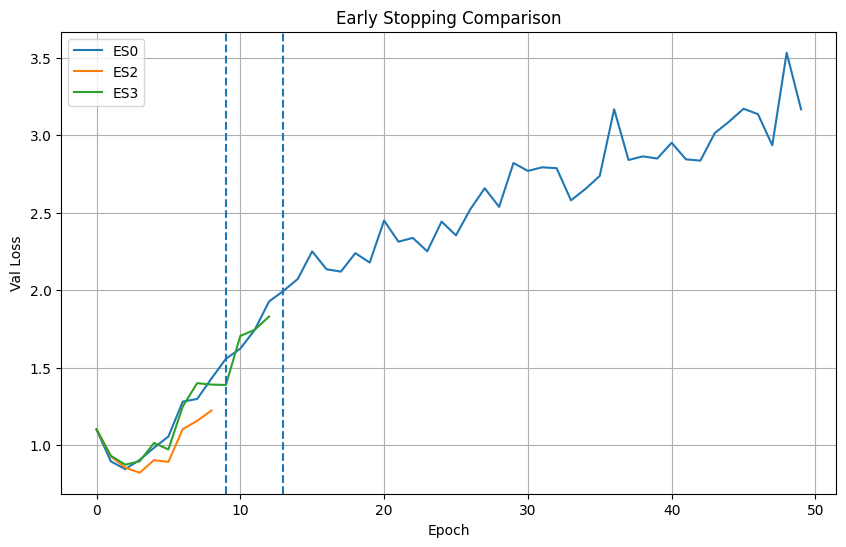

In [29]:
plt.figure(figsize=(10,6))

plt.plot(history_ES0.history['val_loss'], label='ES0')
plt.plot(history_ES2.history['val_loss'], label='ES2')
plt.plot(history_ES3.history['val_loss'], label='ES3')

# vertical lines
plt.axvline(x=stopped_ES2, linestyle='--')
plt.axvline(x=stopped_ES3, linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.title('Early Stopping Comparison')
plt.legend()
plt.grid(True)
plt.show()

Is patience=5 too aggressive? Is patience=10 too lenient?

Patience = 5 can be considered slightly aggressive, as it may stop training too early before the model has fully converged, especially if the validation loss fluctuates temporarily.

On the other hand, patience = 10 is more lenient, as it allows the model to continue training for a longer time. This can help achieve better performance, but it may also increase the risk of overfitting if the model continues training after reaching its optimal point.

## 2C

In [ ]:
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def build_medium_depth():
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def build_deep():
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
models_dict = {
    "Shallow": build_shallow(),
    "Medium": build_medium_depth(),
    "Deep": build_deep()
}

histories = {}
results = []

for name, model in models_dict.items():

    print(f"\nTraining {name} model...")

    model.summary()

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )

    histories[name] = history

    results.append({
        "Model": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })


Training Shallow model...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,754 (2.12 MB)

 Trainable params: 555,754 (2.12 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7264 | Test Loss: 0.8481 | Time: 73.2s


In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(results)
print(df)

     Model  Test Acc  Test Loss       Time
0  Shallow    0.6998   2.286913  68.994043
1   Medium    0.7279   0.786900  69.754354
2     Deep    0.7264   0.848083  73.175436


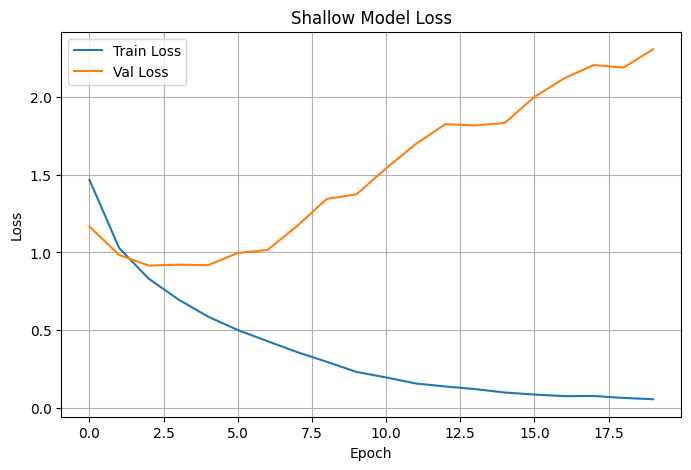

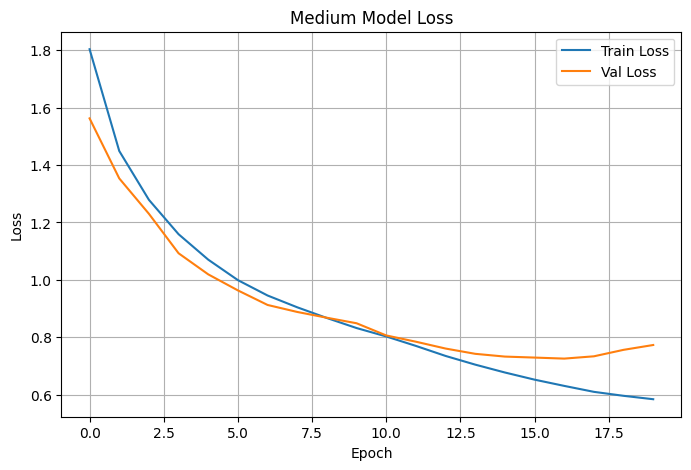

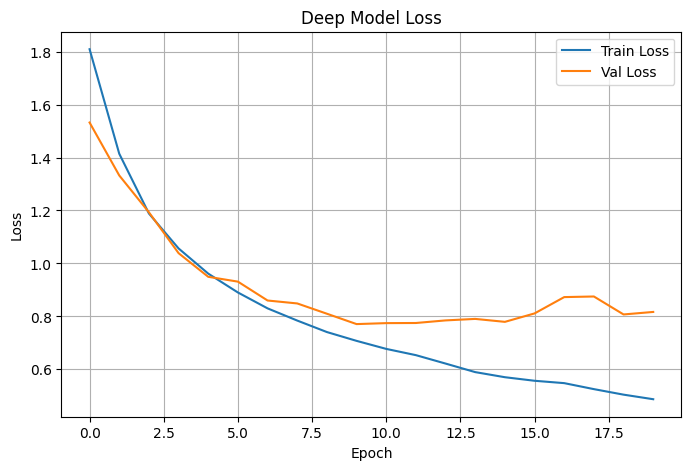

In [ ]:
for name, history in histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')

    plt.title(f'{name} Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

## 4A

In [ ]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

def build_medium_model():
    return build_cnn_model(32, 32, 64, 64)

histories = []
labels = []
results = []

for name, opt in optimizers.items():

    print(f"\nTraining with {name} optimizer...")

    model = build_medium_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )

    histories.append(history)
    labels.append(name)

    results.append({
        "Optimizer": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })




Training with SGD optimizer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.4692 | Test Loss: 1.4960 | Time: 72.8s

Training with Momentum optimizer...
Test Acc: 0.6737 | Test Loss: 0.9632 | Time: 79.1s

Training with AdaGrad optimizer...
Test Acc: 0.5415 | Test Loss: 1.2985 | Time: 74.8s

Training with RMSProp optimizer...
Test Acc: 0.7154 | Test Loss: 2.5013 | Time: 76.4s

Training with Adam optimizer...
Test Acc: 0.7073 | Test Loss: 2.1486 | Time: 77.8s


In [ ]:
df = pd.DataFrame(results)
print(df)

  Optimizer  Test Acc  Test Loss       Time
0       SGD    0.4692   1.495965  72.818312
1  Momentum    0.6737   0.963227  79.083225
2   AdaGrad    0.5415   1.298525  74.778757
3   RMSProp    0.7154   2.501259  76.368725
4      Adam    0.7073   2.148574  77.781518


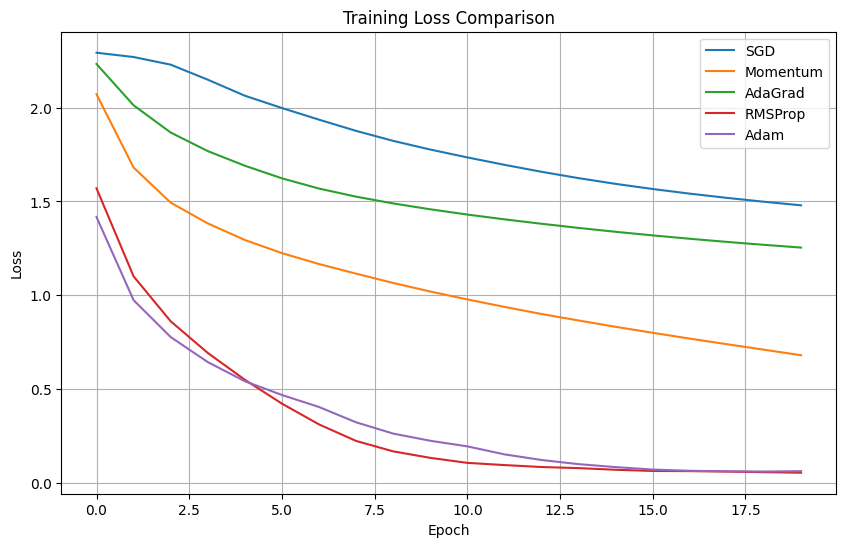

In [ ]:
plot_curves(
    histories,
    labels,
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)

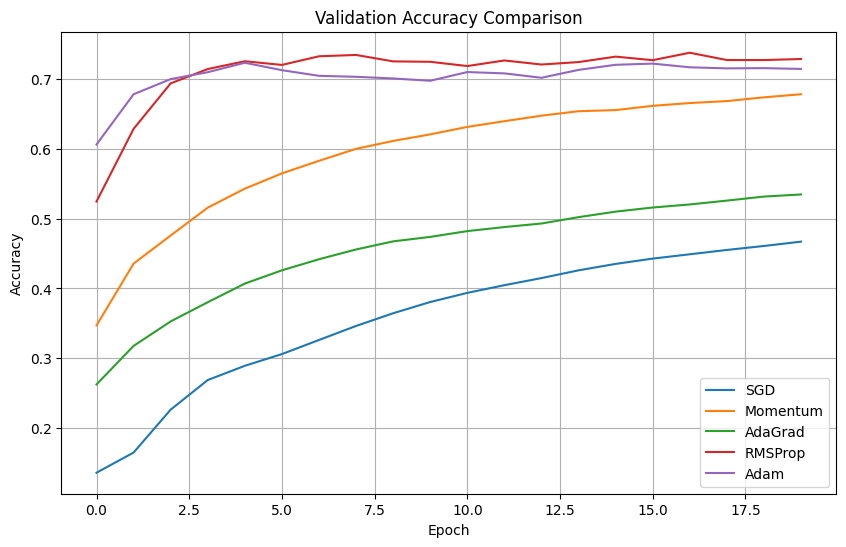

In [ ]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

## 4B

In [ ]:
learning_rates = {
    '0.0001': 0.0001,
    '0.001': 0.001,
    '0.01': 0.01
}
histories = []
labels = []
results = []

for name, lr in learning_rates.items():

    print(f"\nTraining with learning rate = {lr}")

    model = build_medium_model()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=30
    )

    histories.append(history)
    labels.append(name)

    results.append({
        "Learning Rate": lr,
        "Train Loss": history.history['loss'][-1],
        "Val Loss": history.history['val_loss'][-1],
        "Test Acc": test_acc
    })


Training with learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6806 | Test Loss: 1.1175 | Time: 110.0s

Training with learning rate = 0.001
Test Acc: 0.7160 | Test Loss: 2.7136 | Time: 111.6s

Training with learning rate = 0.01
Test Acc: 0.5056 | Test Loss: 1.8176 | Time: 110.0s


In [ ]:
df = pd.DataFrame(results)
print(df)

   Learning Rate  Train Loss  Val Loss  Test Acc
0         0.0001    0.361384  1.083790    0.6806
1         0.0010    0.040191  2.689469    0.7160
2         0.0100    0.961374  1.822569    0.5056


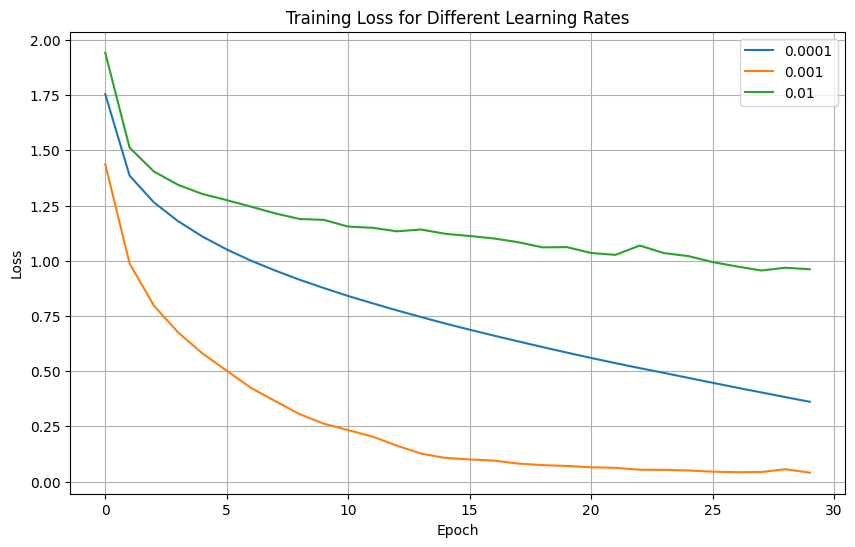

In [ ]:
plot_curves(
    histories,
    labels,
    metric='loss',
    title='Training Loss for Different Learning Rates',
    ylabel='Loss'
)

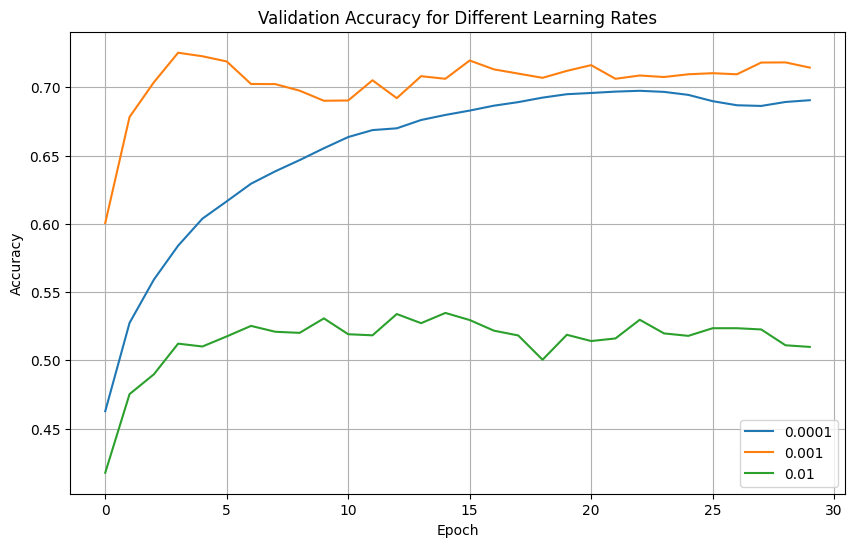

In [ ]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy for Different Learning Rates',
    ylabel='Accuracy'
)

### 6A

### building the medium model (scratch model)

In [ ]:
x_train_resized = tf.image.resize(x_train_std, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_std, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_std, (48, 48)).numpy()
histories = []
test_accs = []
test_losses = []
times = []
models_list = []
f1,f2,f3,f4 = models_config["Medium"]
scratch_model = models.Sequential([
    layers.Conv2D(f1, (3,3), activation='relu', padding='same', input_shape=(48, 48, 3)),
    layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(f3, (3,3), activation='relu', padding='same'),
    layers.Conv2D(f4, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
scratch_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(scratch_model)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### building the freezed vgg model

In [ ]:
vgg_base = keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)
vgg_base.trainable = False
vgg_freezed_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
vgg_freezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(vgg_freezed_model)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


### building the semifreezed vgg model with lower learning rate

In [ ]:
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
vgg_semifreezed_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
vgg_semifreezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(vgg_semifreezed_model)

### building the semifreezed vgg model with high learning rate

In [ ]:
vgg_semifreezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(vgg_semifreezed_model)

### fitting models

In [ ]:
for model in models_list:
    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_resized, y_train,
        x_val_resized, y_val,
        x_test_resized, y_test,
        epochs=20,
        batch_size=128
    )
    print(f" training model: {model}")
    print(model.summary())
    histories.append(history)
    test_accs.append(test_acc)
    test_losses.append(test_loss)
    times.append(t)

Test Acc: 0.6794 | Test Loss: 2.7084 | Time: 152.7s
 training model: <Sequential name=sequential_17, built=True>


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_68 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,283,072 (27.78 MB)

 Trainable params: 2,427,690 (9.26 MB)

...

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,426,646 (55.03 MB)

None


KeyboardInterrupt: 